In [35]:
import sys
sys.path.append("C:/Users/Theo/Documents/Unif/ChimpRec/Code")
from chimplib.imports import YOLO, plt, pd
from chimplib.metric import *

In [36]:
# Load your trained YOLO model

model_prefix = "C:/Users/Theo/Documents/Unif/Models/body/"
model_names = [
    "v8n",
    "v8s",
    "v10n",
    "v10s",
    "v10m"
]  
model_postfix = "/weights/best.pt" # Update with your model paths

images_path = "C:/Users/Theo/Documents/Unif/detection_test_set/images"
labels_path = "C:/Users/Theo/Documents/Unif/detection_test_set/labels"

# images_path = "C:/Users/Theo/Documents/Unif/toy_dataset/images"
# labels_path = "C:/Users/Theo/Documents/Unif/toy_dataset/labels"

output_folder = "C:/Users/Theo/Documents/Unif/ChimpRec/Code/Body_detection/Metric/results/grid_search_results"

In [37]:
GT = extract_ground_truth(labels_path, images_path)

In [38]:
def evaluate_model(model_name, t_iou=0.6):
    model_path = f"{model_prefix}{model_name}{model_postfix}"
    iterators = [i/20 for i in range(1, 20, 1)]

    data = dict()

    for i in iterators:
        pred = predict(model_path, images_path, i)
        print(pred)
        results = extract_metrics(GT, pred, t=t_iou)
        tp, fp, fn = results.values()
        if (tp+fp) == 0: precision = 0
        else: precision=tp/(tp+fp)

        if (tp+fn) == 0: recall = 0
        else: recall=tp/(tp+fn)

        n_pred = 0
        for values in pred.values(): n_pred += len(values)
        data[i] = (precision, recall, n_pred)
    
    if output_folder != "NONE":
        df = pd.DataFrame.from_dict(data, orient="index", columns=["Precision", "Recall", "N_PRED"])
        df.index.name = "Threshold"
        df.to_csv(f"{output_folder}/{model_name}.csv")
    
    return data

In [ ]:
data_general = {}
for model_name in model_names:
    data_general[model_name] = evaluate_model(model_name)

In [40]:
result_matrix_precision = []
result_matrix_recall = []

for model_name in model_names:
    model_data = data_general[model_name]
    model_precisions = []
    model_recalls = []
    for key in model_data.keys():
        precision, recall, _ = model_data[key]
        model_precisions.append(precision)
        model_recalls.append(recall)
    result_matrix_precision.append(model_precisions)
    result_matrix_recall.append(model_recalls)

row_names = model_names
column_names = [i/20 for i in range(1, 20, 1)]


In [45]:
result_matrix_f1 = []
for i in range(len(result_matrix_recall)):
    aux = []
    for j in range(len(result_matrix_recall[i])):
        p, r = result_matrix_precision[i][j], result_matrix_recall[i][j]
        if (p+r == 0): f1 = 0
        else: f1 = (2*p*r)/(p+r)
        aux.append(f1)
    result_matrix_f1.append(aux)

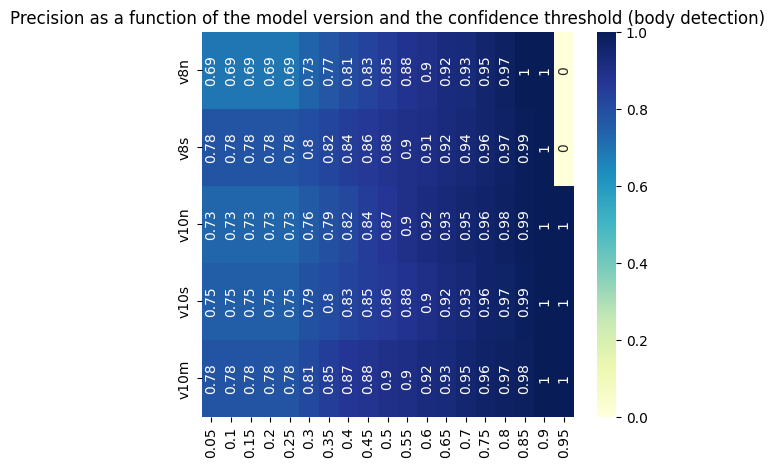

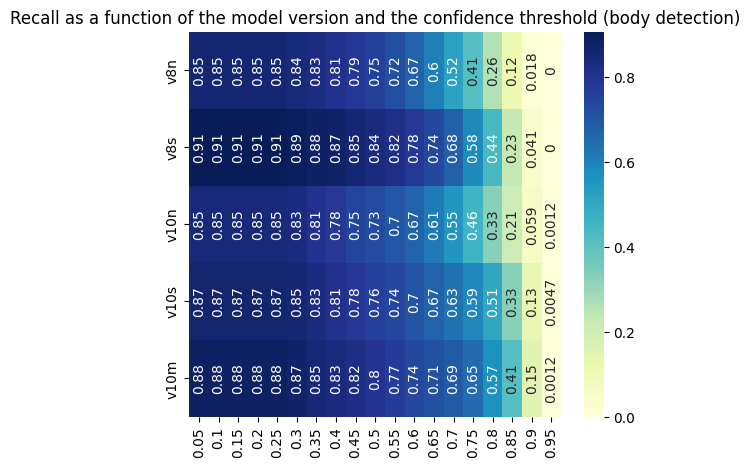

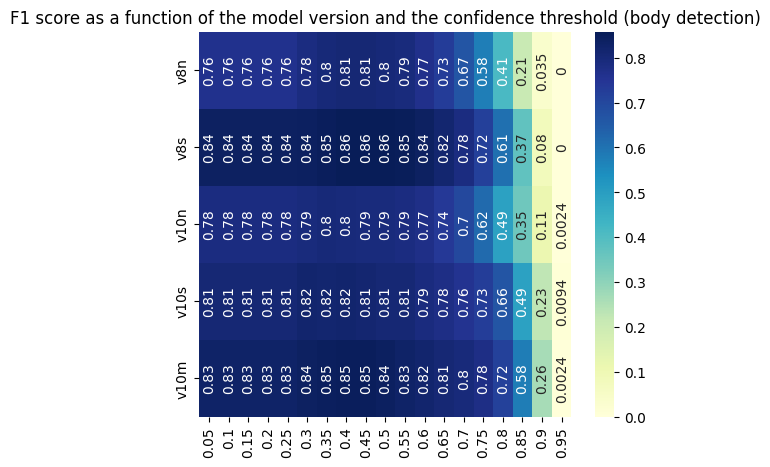

In [48]:
import seaborn as sns

# Convert to DataFrame
df = pd.DataFrame(result_matrix_precision, index=row_names, columns=column_names)

# Plot the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(df, annot=True, cmap="YlGnBu", annot_kws={"rotation": 90})
plt.title("Precision as a function of the model version and the confidence threshold (body detection)")
plt.savefig("C:/Users/Theo/Documents/Unif/ChimpRec/Code/Body_detection/Metric/results/grid_search_results/GS_precision.svg", format="svg")
plt.show()


# Convert to DataFrame
df = pd.DataFrame(result_matrix_recall, index=row_names, columns=column_names)

# Plot the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(df, annot=True, cmap="YlGnBu", annot_kws={"rotation": 90})
plt.title("Recall as a function of the model version and the confidence threshold (body detection)")
plt.savefig("C:/Users/Theo/Documents/Unif/ChimpRec/Code/Body_detection/Metric/results/grid_search_results/GS_recall.svg", format="svg")
plt.show()

# Convert to DataFrame
df = pd.DataFrame(result_matrix_f1, index=row_names, columns=column_names)

# Plot the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(df, annot=True, cmap="YlGnBu", annot_kws={"rotation": 90})
plt.title("F1 score as a function of the model version and the confidence threshold (body detection)")
plt.savefig("C:/Users/Theo/Documents/Unif/ChimpRec/Code/Body_detection/Metric/results/grid_search_results/GS_f1.svg", format="svg")
plt.show()